<a href="https://colab.research.google.com/github/zish-s/Detecting-Parkinson-s-disease/blob/main/Detecting_Parkinson's_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import pandas as pd
import os, sys
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = "/content/drive/MyDrive/datasets/parkinsons[1].data"

In [4]:
df = pd.read_csv(path)
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [5]:
df.size

4680

Parkinson's patients [1] : 147
Healthy patients [0]      : 48


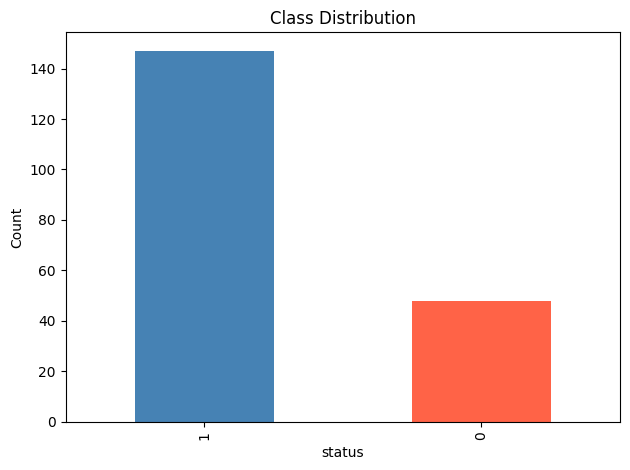

In [17]:
#seperate features from labels
print("Parkinson's patients [1] :", df['status'].value_counts()[1])
print('Healthy patients [0]      :', df['status'].value_counts()[0])

df['status'].value_counts().plot(kind='bar', color=['steelblue','tomato'],
                                 tick_label=['Healthy (0)', "Parkinson's (1)"])
                                 #there are 147 ones, 48 zeroes

plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [20]:
#All other columns except 'status' are our features
features=df.loc[:,df.columns!='status'].values[:,1:]
labels=df.loc[:,'status'].values

#Scale features to range [-1, 1], normalise
scaler=MinMaxScaler((-1,1))
x=scaler.fit_transform(features)
y=labels

print('Features :', x.shape)
print('Labels  :', y.shape)

Features : (195, 22)
Labels  : (195,)


In [22]:
#Splitting the dataset
# 80% for training, 20% for testing
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.2,
                                               random_state=7)

print('training :', x_train.shape)
print('testing  :', x_test.shape)

training : (156, 22)
testing  : (39, 22)


    XGBoost builds many decision trees **one after another**, each one correcting the mistakes of the previous. The final prediction is a weighted combination of all trees.


In [23]:
#train the model
model=XGBClassifier()
model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [25]:
#evaluating the model
y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)*100
print(f'Accuracy: {accuracy:.2f}%')
print()
print(classification_report(y_test, y_pred, target_names=['Healthy', "Parkinson's"]))

Accuracy: 94.87%

              precision    recall  f1-score   support

     Healthy       1.00      0.71      0.83         7
 Parkinson's       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39



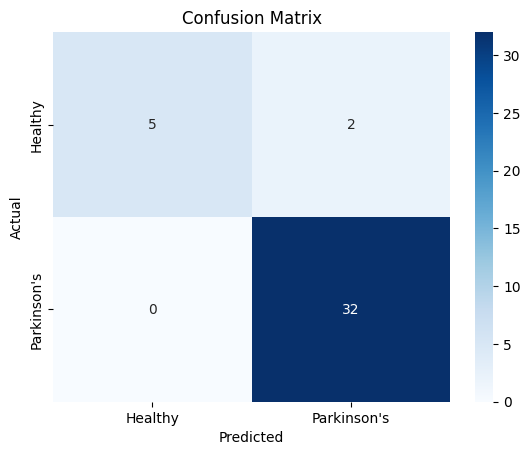

In [27]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Healthy", "Parkinson's"],
            yticklabels=["Healthy", "Parkinson's"])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()